# 04 — Area-level garbage forecasting

Compact notebook for the geographic extension of the garbage-report forecasting project.

**Selected model**

\[
\text{reports} \sim \text{area} + \text{trend} + \text{weekday} + \text{month} + \text{holiday} + \text{recent 7-day activity}
\]

The model is a shared **Poisson GLM** across all areas. `recent7_avg` uses only the previous 7 actual days in the same area, so the validation below is **rolling one-day-ahead**.

This notebook keeps only the results needed to justify and diagnose the final area-level model; the earlier exploratory experiments do not need to remain here.


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works whether Jupyter was launched from the project root or notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.resolve()))

from src.area_forecasting import (
    AREA_FORMULA,
    NO_TREND_FORMULA,
    prepare_area_panel,
    area_sparsity_profile,
    fit_area_poisson,
    evaluate_area_model,
    poisson_dispersion,
    zero_calibration,
    residual_autocorrelation,
    calibration_table,
)

DATA_PATH = PROJECT_ROOT / "data" / "mapped_requests.csv"
TEST_YEARS = [2023, 2024, 2025]


## 1. Load data and build the area-day panel

In [3]:
df = pd.read_csv(DATA_PATH)

garbage_mask = (
    pd.to_datetime(df["reported"], errors="coerce").dt.year.between(2020, 2025)
    & df["issue"].eq("garbage")
)

garbage_rows = df.loc[garbage_mask]

print(f"Garbage reports:        {len(garbage_rows):,}")
print(f"Missing area_name:      {garbage_rows['area_name'].isna().sum():,}")
print(f"Missing area percentage:{100 * garbage_rows['area_name'].isna().mean():.2f}%")

panel = prepare_area_panel(df)

print(f"Areas:                  {panel['area_name'].nunique()}")
print(f"Area-day observations:  {len(panel):,}")
print(f"Date range:              {panel['date'].min().date()} -> {panel['date'].max().date()}")


Garbage reports:        45,621
Missing area_name:      274
Missing area percentage:0.60%
Areas:                  84
Area-day observations:  184,044
Date range:              2020-01-02 -> 2025-12-31


## 2. Compact sparsity check

This replaces the larger `mappedEDA.ipynb`. We only keep the main facts needed for modeling: how active each area is and how often its daily count is zero.


,areas,pct_of_areas
sparsity_band,,
<50% zero days,2,2.38
50–75% zero days,15,17.86
75–90% zero days,36,42.86
90–95% zero days,15,17.86
>95% zero days,16,19.05


Median zero-day percentage: 86.99%
Median reports/day:          0.154


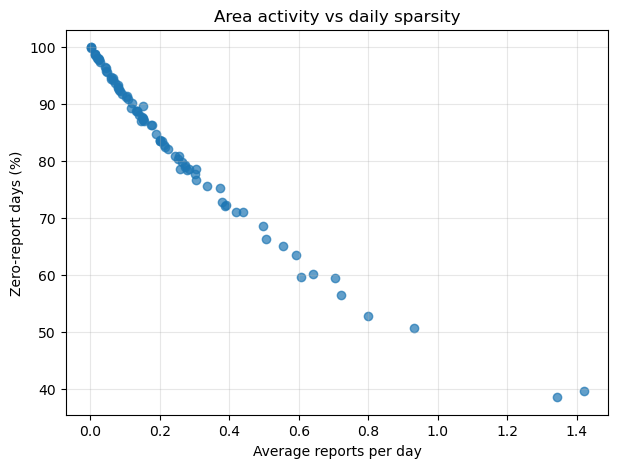

In [4]:
area_profile = area_sparsity_profile(panel)

bins = [0, 50, 75, 90, 95, 100]
labels = [
    "<50% zero days",
    "50–75% zero days",
    "75–90% zero days",
    "90–95% zero days",
    ">95% zero days",
]

area_profile["sparsity_band"] = pd.cut(
    area_profile["zero_day_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

sparsity_summary = (
    area_profile["sparsity_band"]
    .value_counts(sort=False)
    .rename("areas")
    .to_frame()
)
sparsity_summary["pct_of_areas"] = 100 * sparsity_summary["areas"] / len(area_profile)

display(sparsity_summary.round(2))

print(f"Median zero-day percentage: {area_profile['zero_day_pct'].median():.2f}%")
print(f"Median reports/day:          {area_profile['avg_reports_per_day'].median():.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(
    area_profile["avg_reports_per_day"],
    area_profile["zero_day_pct"],
    alpha=0.7,
)
plt.xlabel("Average reports per day")
plt.ylabel("Zero-report days (%)")
plt.title("Area activity vs daily sparsity")
plt.grid(alpha=0.3)
plt.show()


## 3. Final model choice: no trend vs trend

The no-trend model has slightly better raw MAE because most area-days are zero. The trend model is retained because it is much less biased, improves RMSE / Poisson deviance, and performs better on active days — a better fit for operational workload planning.


In [5]:
comparison_rows = []

for name, formula in {
    "no_trend": NO_TREND_FORMULA,
    "with_trend": AREA_FORMULA,
}.items():
    metrics, _ = evaluate_area_model(
        panel,
        formula=formula,
        test_years=TEST_YEARS,
    )

    row = metrics[
        [
            "MAE",
            "RMSE",
            "Poisson_deviance",
            "zero_day_MAE",
            "active_day_MAE",
            "mean_error",
            "mean_actual",
            "mean_predicted",
            "expected_zero_pct",
            "observed_zero_pct",
        ]
    ].mean()

    row.name = name
    comparison_rows.append(row)

model_comparison = pd.DataFrame(comparison_rows)
display(model_comparison.round(4))


,MAE,RMSE,Poisson_deviance,zero_day_MAE,active_day_MAE,mean_error,mean_actual,mean_predicted,expected_zero_pct,observed_zero_pct
no_trend,0.3359,0.6668,0.7391,0.1597,1.0713,0.0674,0.295,0.2277,82.7431,80.6922
with_trend,0.3556,0.6621,0.7238,0.2022,0.9967,0.0088,0.295,0.2862,79.3905,80.6922


## 4. Fit the selected model and check dispersion

In [6]:
selected_model = fit_area_poisson(panel, formula=AREA_FORMULA)

print(f"AIC: {selected_model.aic:.2f}")
display(poisson_dispersion(selected_model).to_frame("value").round(3))


AIC: 188504.77


,value
pearson_dispersion,1.333
deviance_per_df,0.651


## 5. Chronological out-of-sample performance

In [7]:
metrics, oos = evaluate_area_model(
    panel,
    formula=AREA_FORMULA,
    test_years=TEST_YEARS,
)

display(metrics.round(4))

print("Average:")
display(
    metrics[
        [
            "MAE",
            "RMSE",
            "Poisson_deviance",
            "zero_day_MAE",
            "active_day_MAE",
            "mean_error",
        ]
    ].mean().to_frame("mean").T.round(4)
)


,year,MAE,RMSE,Poisson_deviance,zero_day_MAE,active_day_MAE,mean_error,mean_actual,mean_predicted,observed_zero_pct,expected_zero_pct
0,2023,0.3267,0.6244,0.7075,0.1666,1.0240,0.0458,0.2785,0.2327,81.3275,82.3406
1,2024,0.3549,0.6366,0.7044,0.2177,0.9515,-0.0217,0.2775,0.2992,81.3004,78.5595
2,2025,0.3851,0.7254,0.7595,0.2223,1.0145,0.0023,0.3291,0.3268,79.4488,77.2715


Average:


,MAE,RMSE,Poisson_deviance,zero_day_MAE,active_day_MAE,mean_error
mean,0.3556,0.6621,0.7238,0.2022,0.9967,0.0088


## 6. Zero calibration and residual autocorrelation

In [8]:
print("Zero calibration:")
display(zero_calibration(oos).to_frame("value").round(3))

print("\nResidual autocorrelation by area:")
acf = residual_autocorrelation(oos)
display(acf.round(3))


Zero calibration:


,value
observed_zero_pct,80.693
expected_zero_pct,79.390
difference_pp,1.303



Residual autocorrelation by area:


,lag,mean_area_correlation,median_area_correlation,min_area_correlation,max_area_correlation
0,1,0.020,0.014,-0.044,0.124
1,2,0.010,0.007,-0.054,0.118
2,7,0.014,0.006,-0.053,0.107
3,14,0.013,0.006,-0.058,0.164


## 7. Calibration plot

A well-calibrated model should lie close to the diagonal: groups with an average prediction of \(x\) should also average roughly \(x\) observed reports.


,prediction_bin,observations,mean_predicted,mean_actual
0,"(-0.0009999999999597, 0.0225]",9207,0.0093,0.0122
1,"(0.0225, 0.0443]",9206,0.0335,0.0311
2,"(0.0443, 0.0741]",9206,0.0584,0.0579
3,"(0.0741, 0.109]",9207,0.0911,0.1018
4,"(0.109, 0.153]",9206,0.1304,0.1373
5,"(0.153, 0.214]",9206,0.1819,0.2018
6,"(0.214, 0.292]",9207,0.2519,0.2691
7,"(0.292, 0.413]",9206,0.3466,0.3613
8,"(0.413, 0.68]",9206,0.5233,0.5648
9,"(0.68, 7.592]",9207,1.2361,1.2129


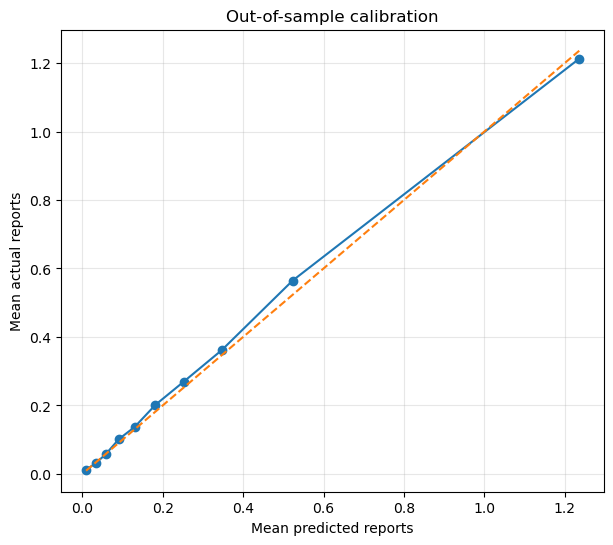

In [9]:
cal = calibration_table(oos, bins=10)
display(cal.round(4))

plt.figure(figsize=(7, 6))
plt.plot(cal["mean_predicted"], cal["mean_actual"], marker="o")

lo = min(cal["mean_predicted"].min(), cal["mean_actual"].min())
hi = max(cal["mean_predicted"].max(), cal["mean_actual"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

plt.xlabel("Mean predicted reports")
plt.ylabel("Mean actual reports")
plt.title("Out-of-sample calibration")
plt.grid(alpha=0.3)
plt.show()


## 8. Inspect the biggest misses

Pearson residuals can become enormous when an ultra-sparse area has an almost-zero prediction and then receives a report. The table below keeps this visible without dumping dozens of diagnostic tables.


In [10]:
largest_misses = (
    oos.assign(abs_pearson=lambda x: x["pearson_residual"].abs())
    .sort_values("abs_pearson", ascending=False)
)

display(
    largest_misses[
        [
            "area_name",
            "date",
            "reports",
            "predicted",
            "recent7_avg",
            "is_holiday",
            "pearson_residual",
        ]
    ].head(15)
)


,area_name,date,reports,predicted,recent7_avg,is_holiday,pearson_residual
24159,Προάστιο,2023-03-11,1,1.727454e-13,0.000000,False,1000000.000000
25503,Πόρτες,2023-11-15,1,8.050007e-13,0.000000,False,999999.999999
25475,Πόρτες,2023-10-18,1,9.696975e-13,0.000000,False,999999.999999
24358,Προάστιο,2023-09-26,1,1.165841e-12,0.000000,False,926147.705581
48129,Κρητικα,2024-09-24,16,1.035061e-01,0.000000,False,49.410396
64775,Αμπελόκηποι,2025-03-28,2,2.652759e-03,0.000000,False,38.779723
3593,Αμπελόκηποι,2023-11-05,1,7.553756e-04,0.000000,False,36.357193
70030,Γουβα,2025-08-20,26,5.289571e-01,0.428571,False,35.021643
4856,Αραχωβίτικα,2023-04-22,4,2.236162e-02,0.142857,False,26.599513
90955,Ψαθόπυργος,2025-12-18,6,5.188916e-02,0.000000,False,26.112035


## Current conclusion

The retained area-level forecasting model is a shared Poisson GLM with:

- area-specific baseline
- linear time trend
- weekday
- month
- Greek public-holiday indicator
- previous-7-day mean for the same area

The main remaining weakness is the set of ultra-sparse areas, where fixed area effects can produce near-zero expected counts. That should be treated as a future modeling question rather than adding arbitrary complexity here.

For now, this notebook is the compact source of truth for daily area-level point forecasting.
